# Feature engineering & Modeling
Last updated: _2022.06.10_

In [1]:
import glob
import pandas as pd

import matplotlib.pyplot as plt

In [2]:
list(glob.glob('output/*.csv'))

['output/dataset_churn_labeled_th8_pr6_20260609.csv',
 'output/dataset_churn_labeled_th8_pr4_20260609.csv']

In [3]:
df_data = pd.read_csv('output/dataset_churn_labeled_th8_pr4_20260609.csv')

In [4]:
print("There are {:,} rows and {:} columns in the raw data.".format(df_data.shape[0], df_data.shape[1]))
print("The dataset contains data from {:} to {:}.".format(df_data['summary_date'].min(), df_data['summary_date'].max()))

There are 544,765 rows and 25 columns in the raw data.
The dataset contains data from 2021-01-01 to 2022-12-31.


In [5]:
df_data['summary_date'] = pd.to_datetime(df_data['summary_date'])
df_data['registration_date'] = pd.to_datetime(df_data['registration_date'])
df_data['firstdeposit_createddate'] = pd.to_datetime(df_data['firstdeposit_createddate'])
df_data['is_churned'] = df_data['is_churned'].astype(int)

In [6]:
df_data.sort_values(['accountid', 'summary_date'], ascending=True, inplace=True)

## Feature engineering

### Date

In [7]:
time_to_first_deposit_age = (
    df_data.groupby("accountid")
        .agg(
            registration_date=("registration_date", "first"),
            first_deposit_date=("firstdeposit_createddate", "first")
        )
    )

time_to_first_deposit_age['time_to_first_deposit_age'] = (
    time_to_first_deposit_age["first_deposit_date"] - time_to_first_deposit_age["registration_date"]
).dt.days

time_to_first_deposit_age = time_to_first_deposit_age.reset_index()
time_to_first_deposit_age.columns = ['accountid', 'registration_date', 'first_deposit_date', 'time_to_first_deposit_age']
time_to_first_deposit_age = time_to_first_deposit_age[['accountid', 'registration_date','time_to_first_deposit_age']].copy() 

In [8]:
time_to_first_deposit_age[:5]

,accountid,registration_date,time_to_first_deposit_age
0,666989420,2020-10-03,0
1,666989923,2020-10-03,0
2,666990238,2020-10-03,0
3,666999616,2020-10-08,0
4,667005177,2020-10-10,374


### Numerical

In [9]:
df_data.columns

Index(['accountid', 'summary_date', 'is_churned', 'bet_type', 'category',
       'secondary_product', 'foundation_category', 'account_tier',
       'activity_channel', 'productgroup', 'registration_date',
       'firstdeposit_createddate', 'plc_betcount', 'plc_turnover_gbp',
       'plc_turnover_gbp_rcash', 'plc_turnover_gbp_bonus', 'stl_betcount',
       'stl_turnover_gbp', 'stl_turnover_gbp_rcash', 'stl_turnover_gbp_bonus',
       'stl_ggr_gbp', 'stl_ggr_gbp_rcash', 'stl_ggr_gbp_bonus', 'deposit_gbp',
       'withdrawal_gbp'],
      dtype='object')

In [10]:
numerical_columns = [
    'plc_betcount', 'plc_turnover_gbp', 'plc_turnover_gbp_rcash', 'plc_turnover_gbp_bonus',
    
    'stl_betcount', 'stl_turnover_gbp', 'stl_turnover_gbp_rcash', 'stl_turnover_gbp_bonus', 'stl_ggr_gbp', 'stl_ggr_gbp_rcash',
    'stl_ggr_gbp_bonus', 'deposit_gbp', 'withdrawal_gbp'
]

In [11]:
df_numerical = df_data[list(['accountid']) + numerical_columns].groupby('accountid', as_index=False).agg({
    'plc_turnover_gbp': ['min', 'mean', 'median', 'max', 'nunique'],
    'plc_turnover_gbp_rcash': ['min', 'mean', 'median', 'max', 'nunique'],
    'plc_turnover_gbp_bonus': ['min', 'mean', 'median', 'max', 'nunique'],
    'plc_betcount': ['min', 'mean', 'median', 'max', 'nunique'],
    
    'stl_turnover_gbp': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_turnover_gbp_rcash': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_turnover_gbp_bonus': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_ggr_gbp': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_ggr_gbp_rcash': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_ggr_gbp_bonus': ['min', 'mean', 'median', 'max', 'nunique'],
    'stl_betcount': ['min', 'mean', 'median', 'max', 'nunique'],

    'deposit_gbp': ['min', 'mean', 'median', 'max', 'nunique'],
    'withdrawal_gbp': ['min', 'mean', 'median', 'max', 'nunique']
})

df_numerical.columns = [
    col[0] if col[1] == '' else f'{col[0]}_{col[1]}'
    for col in df_numerical.columns
]

In [12]:
df_numerical[:5]

,accountid,plc_turnover_gbp_min,plc_turnover_gbp_mean,plc_turnover_gbp_median,plc_turnover_gbp_max,plc_turnover_gbp_nunique,plc_turnover_gbp_rcash_min,plc_turnover_gbp_rcash_mean,plc_turnover_gbp_rcash_median,plc_turnover_gbp_rcash_max,...,deposit_gbp_min,deposit_gbp_mean,deposit_gbp_median,deposit_gbp_max,deposit_gbp_nunique,withdrawal_gbp_min,withdrawal_gbp_mean,withdrawal_gbp_median,withdrawal_gbp_max,withdrawal_gbp_nunique
0,666989420,0.0,0.756415,0.50,15.00,43,0.0,0.703585,0.5,6.00,...,0.0,0.037736,0.0,10.0,2,0.0,0.169811,0.0,20.00,4
1,666989923,0.0,23.413187,5.00,426.00,40,0.0,21.800733,0.0,426.00,...,0.0,4.893773,0.0,137.0,15,0.0,7.700147,0.0,1102.14,3
2,666990238,0.0,9.396947,5.00,110.00,14,0.0,7.087786,0.0,100.00,...,0.0,0.190840,0.0,10.0,2,0.0,4.336565,0.0,250.00,6
3,666999616,0.0,21.793820,9.50,779.00,42,0.0,21.793820,9.5,779.00,...,0.0,7.621723,0.0,340.0,11,0.0,7.762135,0.0,450.00,11
4,667005177,0.0,42.962111,6.25,425.17,114,0.0,41.885986,5.0,425.17,...,0.0,36.175779,0.0,500.0,77,0.0,17.698962,0.0,500.00,17


### One-hot encoding

In [13]:
list(df_data.select_dtypes(object).columns)

['bet_type',
 'category',
 'secondary_product',
 'foundation_category',
 'account_tier',
 'activity_channel',
 'productgroup']

In [14]:
df_data_ohe = pd.get_dummies(df_data[list(['accountid']) + list(df_data.select_dtypes(object).columns)], columns=list(df_data.select_dtypes(object).columns), sparse=False, drop_first=True)

In [15]:
df_data_ohe[:5]

,accountid,bet_type_Others,bet_type_RnG,bet_type_Single,category_Sports,category_eGaming,secondary_product_American Football,secondary_product_Arcade Games,secondary_product_Athletics,secondary_product_Australian Rules Football,...,activity_channel_Not Applicable,activity_channel_Not Available,activity_channel_Tablet,productgroup_Casino,productgroup_Live Casino,productgroup_Lottery,productgroup_Overall,productgroup_Sportsbook,productgroup_Virtual Sports,productgroup_eSports
6386,666989420,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
53668,666989420,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
53669,666989420,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
136896,666989420,False,False,True,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
142978,666989420,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
agg_dict = {col: ["min", "max"] for col in df_data_ohe.columns[1:]}

In [17]:
df_data_ohe_grouped = df_data_ohe.groupby('accountid', as_index=False).agg(agg_dict)

df_data_ohe_grouped.columns = [
    col[0] if col[1] == '' else f'{col[0]}_{col[1]}'
    for col in df_data_ohe_grouped.columns
]

In [18]:
df_data_ohe_grouped[:5]

,accountid,bet_type_Others_min,bet_type_Others_max,bet_type_RnG_min,bet_type_RnG_max,bet_type_Single_min,bet_type_Single_max,category_Sports_min,category_Sports_max,category_eGaming_min,...,productgroup_Lottery_min,productgroup_Lottery_max,productgroup_Overall_min,productgroup_Overall_max,productgroup_Sportsbook_min,productgroup_Sportsbook_max,productgroup_Virtual Sports_min,productgroup_Virtual Sports_max,productgroup_eSports_min,productgroup_eSports_max
0,666989420,False,True,False,True,False,True,False,True,False,...,False,True,False,False,False,True,False,False,False,False
1,666989923,False,False,False,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
2,666990238,False,False,False,False,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
3,666999616,False,False,False,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False
4,667005177,False,False,False,True,False,True,False,True,False,...,False,False,False,False,False,True,False,False,False,False


### Merging

In [19]:
df_training_set = pd.merge(
    time_to_first_deposit_age, # df_training_set
    df_data_ohe_grouped,
    how='left',
    on='accountid'
)

In [20]:
df_training_set = pd.merge(
    df_training_set,
    df_numerical,
    how='left',
    on='accountid'
)

In [21]:
df_training_set.sort_values('accountid', inplace=True)

In [22]:
y = df_data[['accountid', 'registration_date', 'is_churned']].groupby('accountid', as_index=False).agg({
    'registration_date': 'first',
    'is_churned': 'max'
}).sort_values('accountid', inplace=False)

In [23]:
df_training_set[:5]

,accountid,registration_date,time_to_first_deposit_age,bet_type_Others_min,bet_type_Others_max,bet_type_RnG_min,bet_type_RnG_max,bet_type_Single_min,bet_type_Single_max,category_Sports_min,...,deposit_gbp_min,deposit_gbp_mean,deposit_gbp_median,deposit_gbp_max,deposit_gbp_nunique,withdrawal_gbp_min,withdrawal_gbp_mean,withdrawal_gbp_median,withdrawal_gbp_max,withdrawal_gbp_nunique
0,666989420,2020-10-03,0,False,True,False,True,False,True,False,...,0.0,0.037736,0.0,10.0,2,0.0,0.169811,0.0,20.00,4
1,666989923,2020-10-03,0,False,False,False,True,False,True,False,...,0.0,4.893773,0.0,137.0,15,0.0,7.700147,0.0,1102.14,3
2,666990238,2020-10-03,0,False,False,False,False,False,True,False,...,0.0,0.190840,0.0,10.0,2,0.0,4.336565,0.0,250.00,6
3,666999616,2020-10-08,0,False,False,False,True,False,True,False,...,0.0,7.621723,0.0,340.0,11,0.0,7.762135,0.0,450.00,11
4,667005177,2020-10-10,374,False,False,False,True,False,True,False,...,0.0,36.175779,0.0,500.0,77,0.0,17.698962,0.0,500.00,17


In [24]:
y[:5]

,accountid,registration_date,is_churned
0,666989420,2020-10-03,0
1,666989923,2020-10-03,0
2,666990238,2020-10-03,0
3,666999616,2020-10-08,0
4,667005177,2020-10-10,0


In [25]:
df_training = df_training_set[df_training_set['registration_date'] < '2022-01-01'][[i for i in df_training_set.columns if i not in ['accountid', 'registration_date']]]
df_test = df_training_set['2022-01-01' <= df_training_set['registration_date']][[i for i in df_training_set.columns if i not in ['accountid', 'registration_date']]]

In [26]:
df_training.shape, df_test.shape

((1323, 238), (677, 238))

In [27]:
df_training_y = y[y['registration_date'] < '2022-01-01'][[i for i in y.columns if i not in ['accountid', 'registration_date']]]
df_test_y = y['2022-01-01' <= y['registration_date']][[i for i in y.columns if i not in ['accountid', 'registration_date']]]

In [28]:
df_training_y.shape, df_test_y.shape

((1323, 1), (677, 1))

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, cohen_kappa_score, roc_auc_score, precision_recall_curve, auc, confusion_matrix

In [30]:
def calculate_metrics(title, y_true, y_pred):
    precision, recall, thresholds = precision_recall_curve(y_true, y_pred)
    pr_auc_trapz = auc(recall, precision)

    print("{:}\n- Accuracy: {:>15.4f}\n- Precision: {:>14.4f}\n- Recall: {:>17.4f}\n- F1 score: {:>15.4f}\n- Cohen-kappa score: {:>6.4f}\n- ROC AuC: {:>16.4f}\n- PR AuC: {:>17.4f}".format(
        title,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred),
        cohen_kappa_score(y_true, y_pred),
        roc_auc_score(y_true, y_pred),
        pr_auc_trapz
    ))

    print("\nConfusion matrix:\n", confusion_matrix(y_true, y_pred))

- Huge class imbalance (e.g., 0.1% positives): use PR AUC.
- Slight class imbalance (e.g., 30/70 or 40/60): ROC AUC is usually perfectly appropriate, although PR AUC can still provide additional insight.

## Models

### Decision tree

In [31]:
from sklearn.tree import DecisionTreeClassifier

In [32]:
clf = DecisionTreeClassifier(
    max_depth=5,
)

In [33]:
clf.fit(df_training, df_training_y['is_churned'])

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
df_training_y['prediction'] = clf.predict(df_training)
df_test_y['prediction'] = clf.predict(df_test)

In [35]:
calculate_metrics("Training set:", df_training_y['is_churned'], df_training_y['prediction'])

Training set:
- Accuracy:          0.7521
- Precision:         0.7735
- Recall:            0.7468
- F1 score:          0.7599
- Cohen-kappa score: 0.5038
- ROC AuC:           0.7524
- PR AuC:            0.8266

Confusion matrix:
 [[476 152]
 [176 519]]


In [36]:
calculate_metrics("Test set:", df_test_y['is_churned'], df_test_y['prediction'])

Test set:
- Accuracy:          0.6529
- Precision:         0.8138
- Recall:            0.6497
- F1 score:          0.7226
- Cohen-kappa score: 0.2743
- ROC AuC:           0.6549
- PR AuC:            0.8536

Confusion matrix:
 [[136  70]
 [165 306]]


In [37]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample
import numpy as np

n_bootstraps = 100
all_importances = []

for _ in range(n_bootstraps):
    X_boot, y_boot = resample(df_training, df_training_y['is_churned'])

    tree = DecisionTreeClassifier(random_state=None)
    tree.fit(X_boot, y_boot)

    all_importances.append(tree.feature_importances_)

all_importances = np.array(all_importances)

mean_importance = all_importances.mean(axis=0)
std_importance = all_importances.std(axis=0)

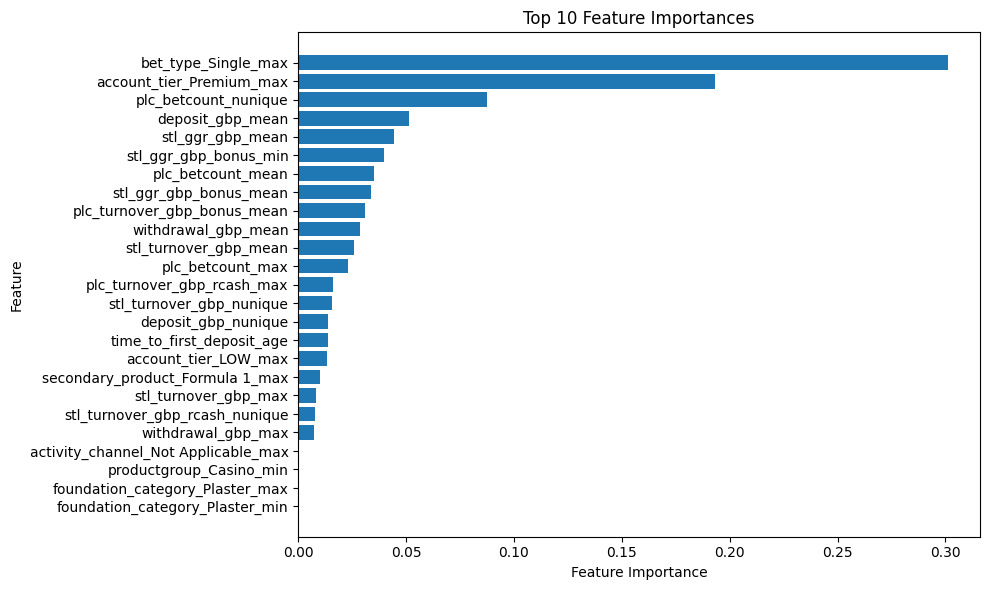

In [38]:
import pandas as pd

# Create a DataFrame with feature names and importances
feature_importance = pd.DataFrame({
    "feature": df_training.columns,
    "importance": clf.feature_importances_
})

# Sort by importance and select the top 10
top10 = (
    feature_importance
    .sort_values("importance", ascending=False)
    .head(25)
    .sort_values("importance")  # Optional: smallest at bottom, largest at top
)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(top10["feature"], top10["importance"])

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 10 Feature Importances")
plt.tight_layout()

plt.show()

### RandomForest

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
clf = RandomForestClassifier()

In [41]:
clf.fit(df_training, df_training_y['is_churned'])

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [42]:
df_training_y['prediction'] = clf.predict(df_training)
df_test_y['prediction'] = clf.predict(df_test)

In [43]:
calculate_metrics("Training set:", df_training_y['is_churned'], df_training_y['prediction'])

Training set:
- Accuracy:          1.0000
- Precision:         1.0000
- Recall:            1.0000
- F1 score:          1.0000
- Cohen-kappa score: 1.0000
- ROC AuC:           1.0000
- PR AuC:            1.0000

Confusion matrix:
 [[628   0]
 [  0 695]]


In [44]:
calculate_metrics("Test set:", df_test_y['is_churned'], df_test_y['prediction'])

Test set:
- Accuracy:          0.6396
- Precision:         0.7918
- Recall:            0.6539
- F1 score:          0.7163
- Cohen-kappa score: 0.2345
- ROC AuC:           0.6304
- PR AuC:            0.8432

Confusion matrix:
 [[125  81]
 [163 308]]


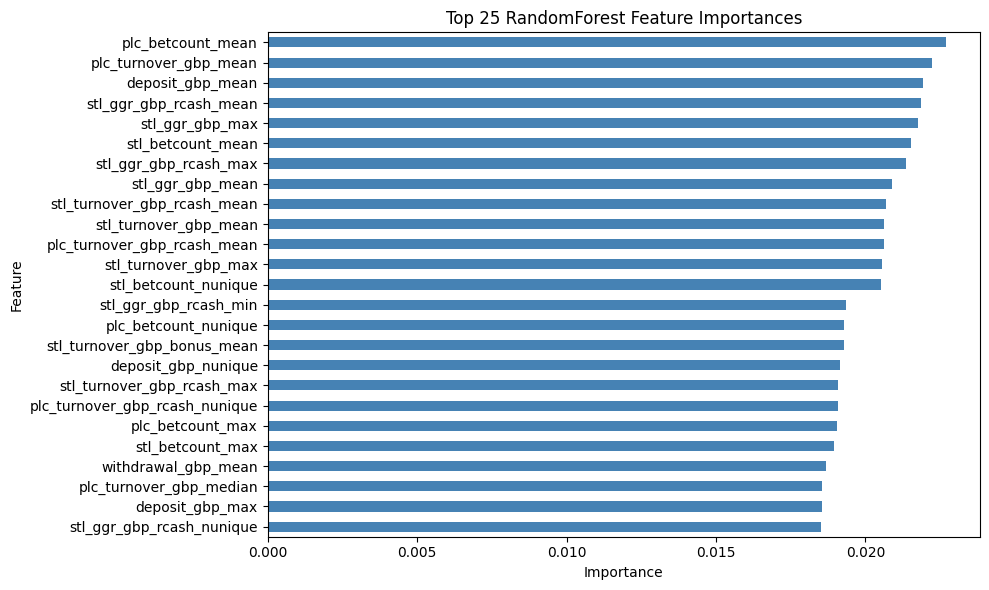

In [45]:
feature_importance = pd.Series(clf.feature_importances_, index=df_training.columns)
top_10_features = feature_importance.sort_values(ascending=False).head(25).sort_values()

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='steelblue')
plt.title('Top 25 RandomForest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### GradientBoosting

In [46]:
from sklearn.ensemble import GradientBoostingClassifier

In [47]:
clf = GradientBoostingClassifier()

In [48]:
clf.fit(df_training, df_training_y['is_churned'])

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [49]:
df_training_y['prediction'] = clf.predict(df_training)
df_test_y['prediction'] = clf.predict(df_test)

In [50]:
calculate_metrics("Training set:", df_training_y['is_churned'], df_training_y['prediction'])

Training set:
- Accuracy:          0.8624
- Precision:         0.8344
- Recall:            0.9209
- F1 score:          0.8755
- Cohen-kappa score: 0.7226
- ROC AuC:           0.8593
- PR AuC:            0.8984

Confusion matrix:
 [[501 127]
 [ 55 640]]


In [51]:
calculate_metrics("Test set:", df_test_y['is_churned'], df_test_y['prediction'])

Test set:
- Accuracy:          0.5968
- Precision:         0.8587
- Recall:            0.5032
- F1 score:          0.6345
- Cohen-kappa score: 0.2479
- ROC AuC:           0.6569
- PR AuC:            0.8538

Confusion matrix:
 [[167  39]
 [234 237]]


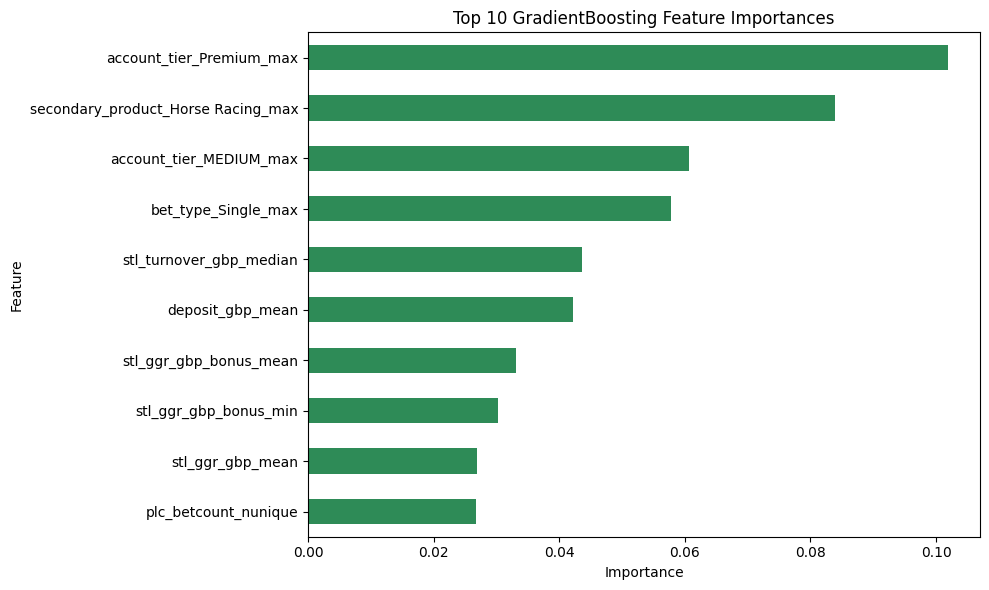

In [52]:
feature_importance = pd.Series(clf.feature_importances_, index=df_training.columns)
top_10_features = feature_importance.sort_values(ascending=False).head(10).sort_values()

plt.figure(figsize=(10, 6))
top_10_features.plot(kind='barh', color='seagreen')
plt.title('Top 10 GradientBoosting Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

#### Parameter tuning

In [53]:
import optuna
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import cross_val_score

/Users/zoltanbalogh/Documents/Source/BV-Group/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [54]:
def objective(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 50, 500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }

    model = GradientBoostingClassifier(
        random_state=42,
        **params
    )

    score = cross_val_score(
        model,
        df_training,
        df_training_y["is_churned"],
        cv=5,
        scoring="average_precision",
    ).mean()

    return score

In [55]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

[I 2026-06-10 09:37:25,214] A new study created in memory with name: no-name-f07bd91d-7342-4780-94e9-01e8a4d47706
[I 2026-06-10 09:37:42,811] Trial 0 finished with value: 0.7165461737866126 and parameters: {'n_estimators': 476, 'learning_rate': 0.17111226984324054, 'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 20, 'subsample': 0.8197369100022005}. Best is trial 0 with value: 0.7165461737866126.
[I 2026-06-10 09:37:49,493] Trial 1 finished with value: 0.7757275777418631 and parameters: {'n_estimators': 490, 'learning_rate': 0.023699431213588255, 'max_depth': 2, 'min_samples_split': 14, 'min_samples_leaf': 4, 'subsample': 0.5509291108750742}. Best is trial 1 with value: 0.7757275777418631.
[I 2026-06-10 09:38:05,835] Trial 2 finished with value: 0.747405505306898 and parameters: {'n_estimators': 254, 'learning_rate': 0.03020593465171462, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 1, 'subsample': 0.7299977656836076}. Best is trial 1 with value: 0.7757275777

In [56]:
study.best_params

{'n_estimators': 218,
 'learning_rate': 0.03304336912168191,
 'max_depth': 2,
 'min_samples_split': 12,
 'min_samples_leaf': 7,
 'subsample': 0.5705572417887106}

In [57]:
study.best_value

0.7837647476526441

In [58]:
best_model = GradientBoostingClassifier(
    random_state=42,
    **study.best_params
)

best_model.fit(
    df_training,
    df_training_y["is_churned"]
)

,loss,'log_loss'
,learning_rate,0.03304336912168191
,n_estimators,218
,subsample,0.5705572417887106
,criterion,'friedman_mse'
,min_samples_split,12
,min_samples_leaf,7
,min_weight_fraction_leaf,0.0
,max_depth,2
,min_impurity_decrease,0.0
,init,None


In [59]:
df_training_y["prediction"] = best_model.predict(df_training)
df_test_y["prediction"] = best_model.predict(df_test)

In [60]:
calculate_metrics("Training set:", df_training_y['is_churned'], df_training_y['prediction'])

Training set:
- Accuracy:          0.7687
- Precision:         0.7484
- Recall:            0.8432
- F1 score:          0.7930
- Cohen-kappa score: 0.5331
- ROC AuC:           0.7647
- PR AuC:            0.8370

Confusion matrix:
 [[431 197]
 [109 586]]


In [61]:
calculate_metrics("Test set:", df_test_y['is_churned'], df_test_y['prediction'])

Test set:
- Accuracy:          0.6263
- Precision:         0.8428
- Recall:            0.5690
- F1 score:          0.6793
- Cohen-kappa score: 0.2699
- ROC AuC:           0.6631
- PR AuC:            0.8558

Confusion matrix:
 [[156  50]
 [203 268]]


In [62]:
df_training_y["probability"] = best_model.predict_proba(df_training)[:, 1]
df_test_y["probability"] = best_model.predict_proba(df_test)[:, 1]

In [63]:
from sklearn.metrics import (
    average_precision_score,
    roc_auc_score,
)

print(
    "Training PR AUC:",
    average_precision_score(
        df_training_y["is_churned"],
        df_training_y["probability"]
    )
)

print(
    "Test PR AUC:",
    average_precision_score(
        df_test_y["is_churned"],
        df_test_y["probability"]
    )
)

print(
    "Training ROC AUC:",
    roc_auc_score(
        df_training_y["is_churned"],
        df_training_y["probability"]
    )
)

print(
    "Test ROC AUC:",
    roc_auc_score(
        df_test_y["is_churned"],
        df_test_y["probability"]
    )
)

Training PR AUC: 0.8583291093214462
Test PR AUC: 0.8266710249421595
Training ROC AUC: 0.8558401686294277
Test ROC AUC: 0.718611506194216


In [64]:
import joblib
import datetime

joblib.dump(best_model, "output/gradient_boosting_churn_model_{:%Y%m%d}.pkl".format(datetime.datetime.now()))

['output/gradient_boosting_churn_model_20260610.pkl']

### Dense neural network

In [65]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l1
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision, Recall

In [66]:
model_type = 'dense'
model = Sequential(name=model_type)
model.add(layers.Input(shape=(df_training.shape[1],)))
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.1))
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.1))
model.add(layers.Dense(1, activation='sigmoid'))
optimizer_adam = Adam(learning_rate=0.0003)
model.compile(optimizer=optimizer_adam, loss='binary_crossentropy', metrics=[
        'accuracy',
        AUC(name='auc'),
        Precision(name='precision'),
        Recall(name='recall')
    ])
model.summary()

Model: "dense"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               30592     
                                                                 
 dropout (Dropout)           (None, 128)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_2 (Dense)             (None, 1)                 65        
                                                                 
Total params: 38913 (152.00 KB)
Trainable params: 38913 (152.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [67]:
history = model.fit(
    df_training.astype('float32'),
    df_training_y['is_churned'].astype('float32').values,
    epochs=100,
    shuffle=False,
    verbose=2,
    validation_data=(df_test.astype('float32'), df_test_y['is_churned'].astype('float32').values),
    batch_size=128,
    callbacks=[
        #EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=5, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.3, cooldown=2, patience=2, min_lr=0.00001)
    ]
)

Epoch 1/100
11/11 - 0s - loss: 55.3056 - accuracy: 0.5336 - auc: 0.5337 - precision: 0.5552 - recall: 0.5640 - val_loss: 17.5216 - val_accuracy: 0.6854 - val_auc: 0.5271 - val_precision: 0.7074 - val_recall: 0.9342 - lr: 3.0000e-04 - 357ms/epoch - 32ms/step
Epoch 2/100
11/11 - 0s - loss: 47.6417 - accuracy: 0.5117 - auc: 0.5129 - precision: 0.5353 - recall: 0.5353 - val_loss: 15.9054 - val_accuracy: 0.6691 - val_auc: 0.6061 - val_precision: 0.7568 - val_recall: 0.7728 - lr: 3.0000e-04 - 19ms/epoch - 2ms/step
Epoch 3/100
11/11 - 0s - loss: 37.4406 - accuracy: 0.5578 - auc: 0.5622 - precision: 0.5703 - recall: 0.6417 - val_loss: 10.3662 - val_accuracy: 0.6765 - val_auc: 0.5698 - val_precision: 0.7316 - val_recall: 0.8450 - lr: 3.0000e-04 - 19ms/epoch - 2ms/step
Epoch 4/100
11/11 - 0s - loss: 36.0372 - accuracy: 0.5208 - auc: 0.5316 - precision: 0.5514 - recall: 0.4705 - val_loss: 13.8381 - val_accuracy: 0.6499 - val_auc: 0.5911 - val_precision: 0.7448 - val_recall: 0.7558 - lr: 3.0000e-0

In [68]:
def plot_history(history):
    plt.style.use('ggplot')

    accuracy = history.history.get('accuracy', [])
    val_accuracy = history.history.get('val_accuracy', [])
    loss = history.history.get('loss', [])
    val_loss = history.history.get('val_loss', [])
    epochs = range(1, len(loss) + 1)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    if accuracy:
        plt.plot(epochs, accuracy, 'b', label='Training accuracy')
    if val_accuracy:
        plt.plot(epochs, val_accuracy, 'r', label='Validation accuracy')
    plt.title('Training and validation accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    if loss:
        plt.plot(epochs, loss, 'b', label='Training loss')
    if val_loss:
        plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Training and validation loss')
    plt.legend()

Training Accuracy: 0.6379
Testing Accuracy: 0.6632


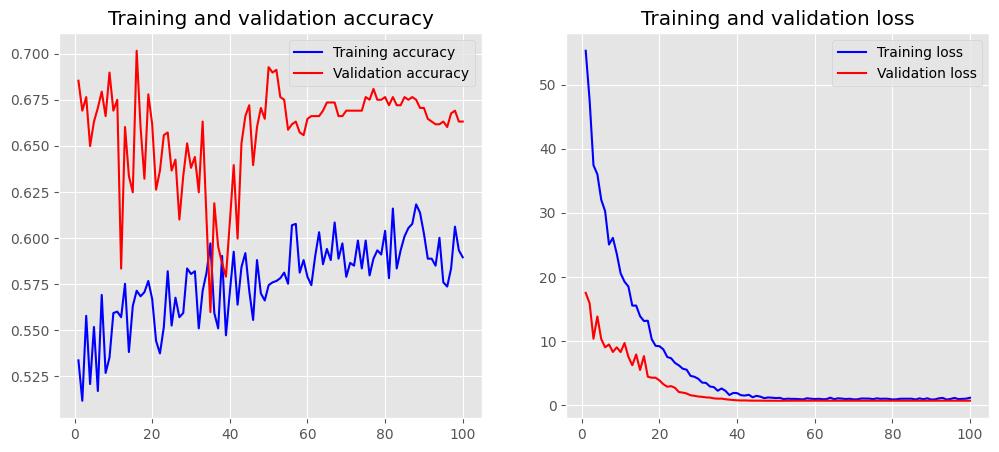

In [69]:
training_metrics = model.evaluate(
    df_training.astype('float32'),
    df_training_y['is_churned'].astype('float32').values,
    verbose=0,
    return_dict=True
)
print("Training Accuracy: {:.4f}".format(training_metrics['accuracy']))
testing_metrics = model.evaluate(
    df_test.astype('float32'),
    df_test_y['is_churned'].astype('float32').values,
    verbose=0,
    return_dict=True
)
print("Testing Accuracy: {:.4f}".format(testing_metrics['accuracy']))
plot_history(history) # 0.76/0.73

In [70]:
train_probs = model.predict(df_training.astype('float32'))

42/42 [==============================] - 0s 299us/step


In [71]:
df_training_y['prediction'] = (train_probs >= 0.5).astype(int)

In [72]:
calculate_metrics("Training set:", df_training_y['is_churned'], df_training_y['prediction'])

Training set:
- Accuracy:          0.6379
- Precision:         0.6195
- Recall:            0.8058
- F1 score:          0.7004
- Cohen-kappa score: 0.2622
- ROC AuC:           0.6290
- PR AuC:            0.7636

Confusion matrix:
 [[284 344]
 [135 560]]


In [73]:
test_probs = model.predict(df_test.astype('float32'))

22/22 [==============================] - 0s 322us/step


In [74]:
df_test_y['prediction'] = (test_probs >= 0.5).astype(int)

In [75]:
calculate_metrics("Test set:", df_test_y['is_churned'], df_test_y['prediction'])

Test set:
- Accuracy:          0.6632
- Precision:         0.7526
- Recall:            0.7686
- F1 score:          0.7605
- Cohen-kappa score: 0.1936
- ROC AuC:           0.5955
- PR AuC:            0.8411

Confusion matrix:
 [[ 87 119]
 [109 362]]


In [76]:
from sklearn.metrics import roc_auc_score

from tqdm import tqdm

100%|██████████| 238/238 [01:00<00:00,  3.95it/s]


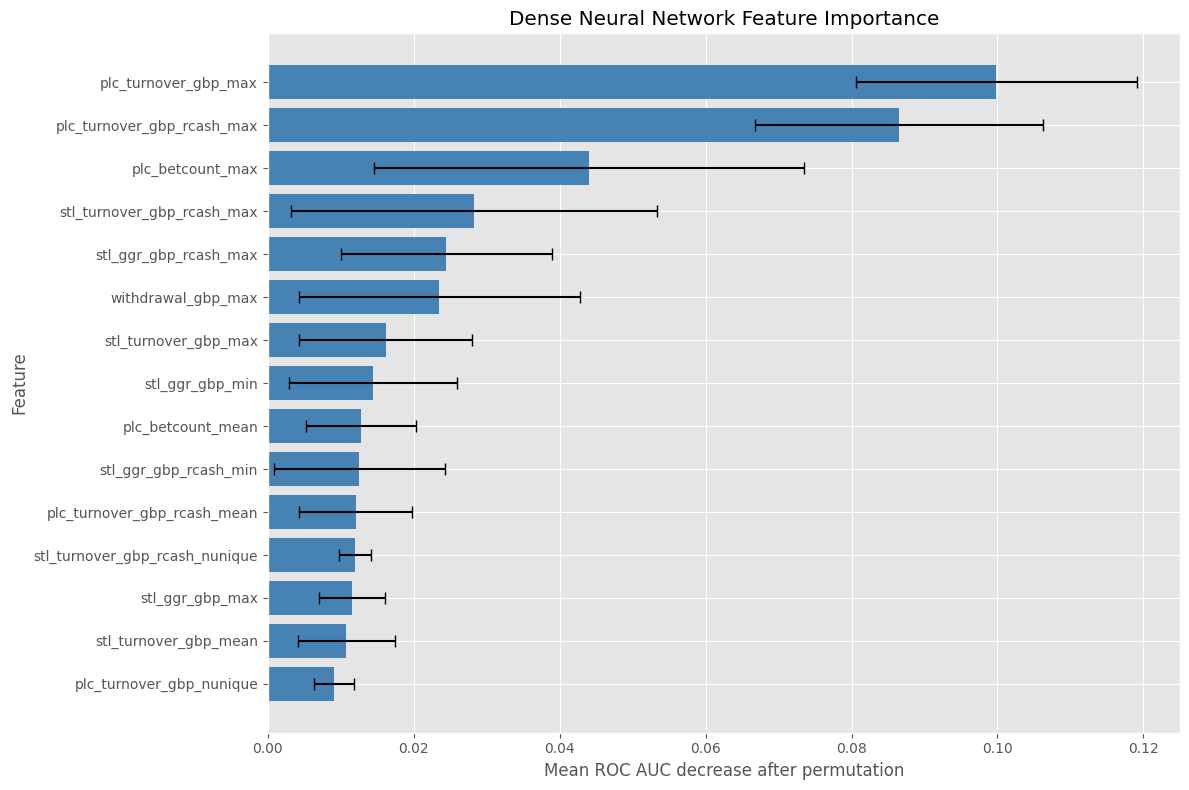

,feature,importance_mean,importance_std
0,plc_turnover_gbp_max,0.099840,0.019226
1,plc_turnover_gbp_rcash_max,0.086531,0.019725
2,plc_betcount_max,0.044067,0.029443
3,stl_turnover_gbp_rcash_max,0.028283,0.025070
4,stl_ggr_gbp_rcash_max,0.024454,0.014440
5,withdrawal_gbp_max,0.023511,0.019220
6,stl_turnover_gbp_max,0.016146,0.011895
7,stl_ggr_gbp_min,0.014450,0.011478
8,plc_betcount_mean,0.012749,0.007529
9,stl_ggr_gbp_rcash_min,0.012564,0.011740


In [77]:
rng = np.random.default_rng(42)
X_importance = df_test.astype('float32').copy()
y_importance = df_test_y['is_churned'].astype('float32').values

baseline_predictions = model.predict(X_importance, verbose=0).ravel()
baseline_auc = roc_auc_score(y_importance, baseline_predictions)

n_repeats = 10
importance_rows = []

for feature_name in tqdm(X_importance.columns):
    score_drops = []
    for _ in range(n_repeats):
        X_permuted = X_importance.copy()
        X_permuted[feature_name] = rng.permutation(X_permuted[feature_name].values)
        permuted_predictions = model.predict(X_permuted, verbose=0).ravel()
        permuted_auc = roc_auc_score(y_importance, permuted_predictions)
        score_drops.append(baseline_auc - permuted_auc)
    importance_rows.append({
        'feature': feature_name,
        'importance_mean': np.mean(score_drops),
        'importance_std': np.std(score_drops)
    })

importance_df = (
    pd.DataFrame(importance_rows)
    .sort_values('importance_mean', ascending=False)
    .reset_index(drop=True)
)

top_n = min(15, len(importance_df))
plot_df = importance_df.head(top_n).sort_values('importance_mean')

plt.style.use('ggplot')
plt.figure(figsize=(12, 8))
plt.barh(
    plot_df['feature'],
    plot_df['importance_mean'],
    xerr=plot_df['importance_std'],
    color='steelblue',
    ecolor='black',
    capsize=4
)
plt.xlabel('Mean ROC AUC decrease after permutation')
plt.ylabel('Feature')
plt.title('Dense Neural Network Feature Importance')
plt.tight_layout()
plt.show()

importance_df.head(top_n)

In [78]:
import shap

PermutationExplainer explainer: 201it [01:09,  2.56it/s]                         


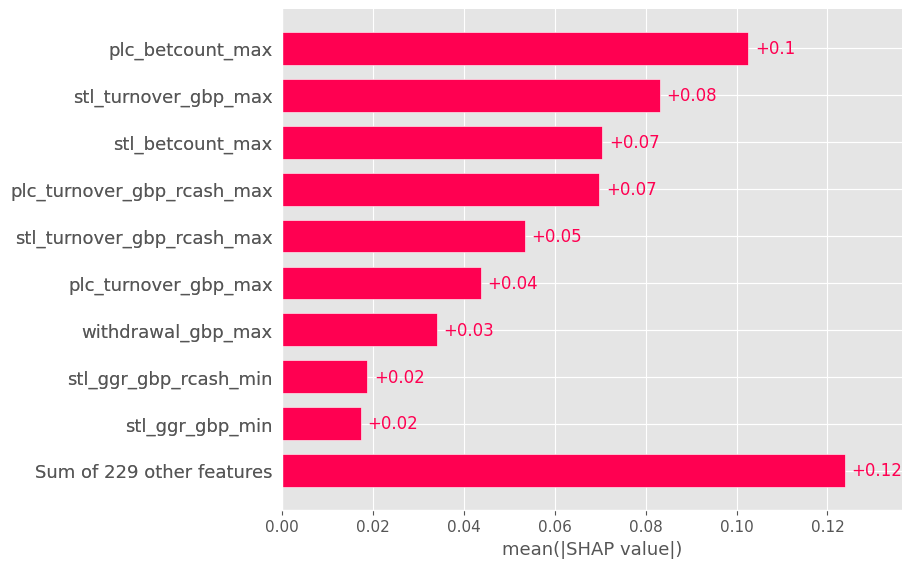

In [79]:
shap_background = df_training.astype('float32').sample(min(200, len(df_training)), random_state=42)
shap_sample = df_test.head(200).astype('float32')

def shap_model_predict(data):
    data = np.asarray(data, dtype=np.float32)
    return model.predict(data, verbose=0).reshape(-1)

masker = shap.maskers.Independent(shap_background.to_numpy(dtype=np.float32))
explainer = shap.Explainer(
    shap_model_predict,
    masker,
    feature_names=shap_background.columns.tolist()
)

shap_values = explainer(shap_sample.to_numpy(dtype=np.float32))

shap.plots.bar(shap_values)

## Summary

| Churn threshold | Outlier cutoff precision (decimal points) | Model | Train F1 score | Train ROC AuC | Train PR AuC | Test F1 score | Test ROC AuC | Test PR AuC |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 8 days | 6 | Decision Tree | 0.7601 | 0.7532 | 0.8273 | 0.7237 | 0.6484 | 0.8511 | 
| 8 days | 6 | Random Forest | 1.0000 | 1.0000 | 1.0000 | 0.7185 | 0.6466 | 0.8498 |
| 8 days | 6 | Gredient Boosting | 0.8789 | 0.8631 | 0.9010 | 0.6393 | 0.6539 | 0.8515 |
| 8 days | 6 | Gredient Boosting (tuned) | - | 0.8512 | 0.8577 | - | 0.71316 | 0.8223 |
| 8 days | 6 | Dense neural network | 0.6658 | 0.6170 | 0.7436 | 0.7289 | 0.5903 | 0.8324 |
| 8 days | 4 | Decision Tree | 0.7599 | 0.7524 | 0.8266 | 0.7226 | 0.6549 | 0.8536 |
| 8 days | 4 | Random Forest | 1.0000 | 1.0000 | 1.0000 | 0.7163 | 0.6304 | 0.8432 |
| 8 days | 4 | Gredient Boosting | 0.8755 | 0.8593 | 0.8984 | 0.6345 | 0.6569 | 0.8538 |
| 8 days | 4 | Gredient Boosting (tuned) | - | 0.8558 | 0.8583 | - | 0.7186 | 0.8267 |
| 8 days | 4 | Dense neural network | 0.7004 | 0.6290 | 0.7636 | 0.7605 | 0.5955 | 0.8411 |